<a href="https://colab.research.google.com/github/ArchieJain120/ML_LAB/blob/main/1BM23CS049_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

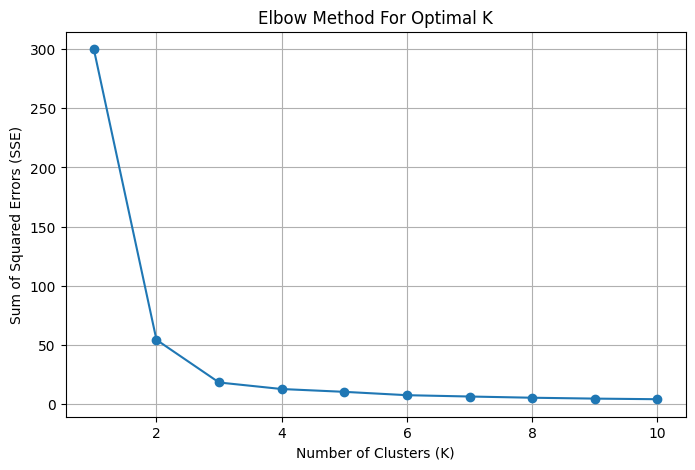

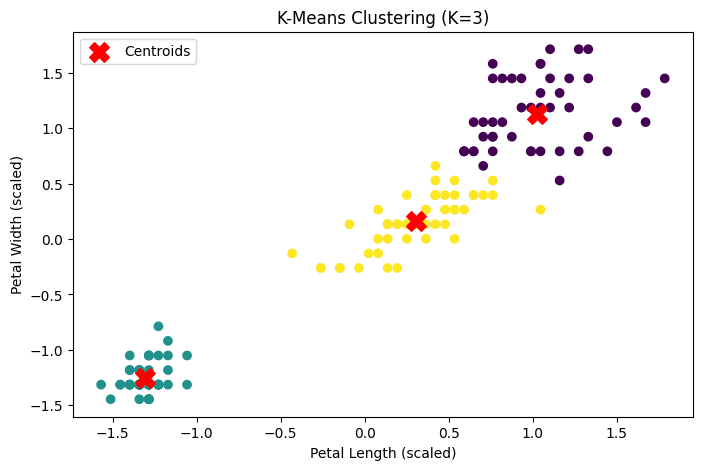

Cluster Centers (scaled):
[[ 1.02813193  1.12749028]
 [-1.30487835 -1.25512862]
 [ 0.30564587  0.16609419]]


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/iris (1) (1) (1).csv')

X = df[['petal_length', 'petal_width']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sse = []

K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)  # inertia = SSE

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_pred

plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            color='red', marker='X', s=200, label='Centroids')

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('K-Means Clustering (K=3)')
plt.legend()
plt.show()

print("Cluster Centers (scaled):")
print(kmeans.cluster_centers_)